# GlucoSense Pilot Data Verification & Analysis Notebook
This notebook allows you to load your pilot dataset (`glucosense_dataset_2026-06-26.csv`), check the length of the photoplethysmogram (PPG) samples, and process the raw wave signals using the **NeuroKit2** bio-signal library.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load the Pilot Dataset

In [6]:
csv_path = "data/test/glucosense_dataset_2026-08-06.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded {csv_path}")
    print(f"Dataset shape: {df.shape} (Rows, Columns)")
    display(df.head(3))
else:
    print(f"Error: File not found at '{csv_path}'. Please verify the path.")

Successfully loaded data/test/glucosense_dataset_2026-08-06.csv
Dataset shape: (40, 13) (Rows, Columns)


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,df829fd3-4238-4378-ae7c-7857c323f433,2026-06-22T15:10:33.034687+00:00,P001,30,Male,34,150,2,NaN,fasting,120,3500,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;...
1,4554cebf-b77c-4838-b9c8-c9e09a58cc1c,2026-06-22T19:31:26.321501+00:00,P001,30,Male,34,150,2,NaN,1hr_post_prandial,110,3500,53219;52810;52322;51886;51566;51288;51043;5085...
2,1f367c29-80e7-47d1-8e08-b039ead4cbe3,2026-06-22T20:10:38.428949+00:00,P001,30,Male,34,150,2,NaN,2hr_post_prandial,134,3500,49184;49195;49234;49254;49303;49329;49373;4933...


## 2. Check PPG Signal Lengths
Here we verify if the semicolon-separated string format parses correctly and if the sample length matches exactly **3,500 samples** (70 seconds of acquisition at 50 Hz, as per the firmware spec).

In [7]:
# Extract and parse PPG signals from all valid sessions
valid_rows = []
for idx, row in df.iterrows():
    ppg_raw_str = row['ppg_data']
    if pd.isna(ppg_raw_str):
        continue
    
    # Split the semicolon-separated string into a list of floats
    samples = [float(x) for x in str(ppg_raw_str).split(';') if x.strip()]
    
    # Only include active rows with actual signals (not all zeros)
    if len(samples) > 0 and sum(samples) > 0:
        valid_rows.append((idx, row, samples))

print(f"Found {len(valid_rows)} valid sessions with active PPG waveforms.\n")

for idx, row, samples in valid_rows:
    print(f"Session Index: {idx} | Participant ID: {row['participant_id']}")
    print(f"  Timing Kind: {row['session_kind']} | BGL: {row['bgl_mgdl']} mg/dL")
    print(f"  Reported Sample Count: {row['ppg_samples_count']}")
    print(f"  Actual Parsed Samples: {len(samples)}")
    print(f"  Length Correct (3,500): {len(samples) == 3500} ✓" if len(samples) == 3500 else "  Length Correct: FALSE ❌")
    print("-" * 50)

Found 39 valid sessions with active PPG waveforms.

Session Index: 1 | Participant ID: P001
  Timing Kind: 1hr_post_prandial | BGL: 110 mg/dL
  Reported Sample Count: 3500
  Actual Parsed Samples: 3500
  Length Correct (3,500): True ✓
--------------------------------------------------
Session Index: 2 | Participant ID: P001
  Timing Kind: 2hr_post_prandial | BGL: 134 mg/dL
  Reported Sample Count: 3500
  Actual Parsed Samples: 3500
  Length Correct (3,500): True ✓
--------------------------------------------------
Session Index: 3 | Participant ID: P002
  Timing Kind: fasting | BGL: 100 mg/dL
  Reported Sample Count: 3500
  Actual Parsed Samples: 3500
  Length Correct (3,500): True ✓
--------------------------------------------------
Session Index: 4 | Participant ID: P002
  Timing Kind: 1hr_post_prandial | BGL: 142 mg/dL
  Reported Sample Count: 3500
  Actual Parsed Samples: 3500
  Length Correct (3,500): True ✓
--------------------------------------------------
Session Index: 5 | Par

## 3. Bio-Signal Processing with NeuroKit2 (All Valid Rows)
We process **all valid sessions** using the **last 3,000 samples** (ignoring the first 500 samples corresponding to 10 seconds of finger placement stabilization noise).

In [8]:
sampling_rate = 50  # 50 Hz sampling rate
processed_data = []

print("--- Processing All Valid Sessions (Ignoring first 500 stabilization samples) ---\n")
for idx, row, ppg_signal in valid_rows:
    ppg_signal = np.array(ppg_signal)
    
    # Use the last 3000 samples (ignore first 500)
    sliced_signal = ppg_signal[500:3500]
    
    try:
        # Clean signal
        cleaned = nk.ppg_clean(sliced_signal, sampling_rate=sampling_rate, method='elgendi')
        
        # Detect systolic peaks
        peaks_dict = nk.ppg_findpeaks(cleaned, sampling_rate=sampling_rate, method='elgendi')
        peaks = peaks_dict['PPG_Peaks']
        
        # Calculate instant heart rate based on peak intervals
        hr = nk.signal_rate(peaks, sampling_rate=sampling_rate, desired_length=len(cleaned))
        avg_hr = np.mean(hr)
        
        # Process with NeuroKit2 pipeline for built-in plotting
        signals, info = nk.ppg_process(sliced_signal, sampling_rate=sampling_rate, method='elgendi')
        
        print(f"Row {idx} ({row['participant_id']} - {row['session_kind']}):")
        print(f"  Beats detected in 60s: {len(peaks)} | Avg HR: {avg_hr:.1f} BPM | BGL: {row['bgl_mgdl']} mg/dL")
        print("-" * 40)
        
        processed_data.append({
            'index': idx,
            'row': row,
            'ppg_signal': sliced_signal,
            'cleaned': cleaned,
            'peaks': peaks,
            'avg_hr': avg_hr,
            'signals': signals,
            'info': info
        })
    except Exception as e:
        print(f"Row {idx} failed to process: {e}")

--- Processing All Valid Sessions (Ignoring first 500 stabilization samples) ---

Row 1 (P001 - 1hr_post_prandial):
  Beats detected in 60s: 67 | Avg HR: 68.0 BPM | BGL: 110 mg/dL
----------------------------------------
Row 2 (P001 - 2hr_post_prandial):
  Beats detected in 60s: 73 | Avg HR: 73.0 BPM | BGL: 134 mg/dL
----------------------------------------
Row 3 (P002 - fasting):
  Beats detected in 60s: 76 | Avg HR: 76.9 BPM | BGL: 100 mg/dL
----------------------------------------
Row 4 (P002 - 1hr_post_prandial):
  Beats detected in 60s: 70 | Avg HR: 70.8 BPM | BGL: 142 mg/dL
----------------------------------------
Row 5 (P0003 - fasting):
  Beats detected in 60s: 79 | Avg HR: 81.2 BPM | BGL: 130 mg/dL
----------------------------------------
Row 6 (P0003 - 1hr_post_prandial):
  Beats detected in 60s: 100 | Avg HR: 103.4 BPM | BGL: 21 mg/dL
----------------------------------------
Row 7 (P0003 - 2hr_post_prandial):
  Beats detected in 60s: 96 | Avg HR: 96.8 BPM | BGL: 89 mg/dL
---

In [5]:
# New cell code to export the processed pilot database as a reference CSV
if processed_data:
    import pandas as pd
    
    csv_rows = []
    for item in processed_data:
        row = item['row']
        peaks = item['peaks']
        
        # 1. Compute HRV intervals (20ms per sample at 50Hz)
        nn_intervals = np.diff(peaks) * 20.0 
        
        # 2. Extract features matching C++ and train_and_generate.py specifications
        sdnn = np.std(nn_intervals) if len(nn_intervals) > 0 else 0.0
        nn_diff = np.diff(nn_intervals)
        rmssd = np.sqrt(np.mean(nn_diff ** 2)) if len(nn_diff) > 0 else 0.0
        ppg_amp = np.std(item['cleaned'])
        
        csv_rows.append({
            'session_id': row.get('session_id', ''),
            'created_at': row.get('created_at', ''),
            'participant_id': row.get('participant_id', ''),
            'age': row.get('age', 0),
            'gender': row.get('gender', ''),
            'weight_kg': row.get('weight_kg', 0.0),
            'height_cm': row.get('height_cm', 0.0),
            'years_on_t2dm': row.get('years_on_t2dm', 0),
            'medication': row.get('medication', '') if pd.notna(row.get('medication')) else '',
            'session_kind': row.get('session_kind', ''),
            'bgl_mgdl': row.get('bgl_mgdl', 0.0),
            'beats_detected': len(peaks),
            'avg_hr': item['avg_hr'],
            'sdnn': sdnn,
            'rmssd': rmssd,
            'ppg_amp': ppg_amp
        })
        
    processed_df = pd.DataFrame(csv_rows)
    processed_csv_path = csv_path.replace(".csv", "_processed.csv")
    processed_df.to_csv(processed_csv_path, index=False)
    print(f"✓ Processed dataset successfully exported to:\n  {processed_csv_path}")
else:
    print("Error: No processed data available. Make sure to run the processing cell first.")


✓ Processed dataset successfully exported to:
  data/test/glucosense_dataset_2026-07-24_processed.csv


## 4. Waveform Visualization
Choose a session index from your processed data list below to view its raw and peak-detected waveforms for the post-stabilization 60-second window.

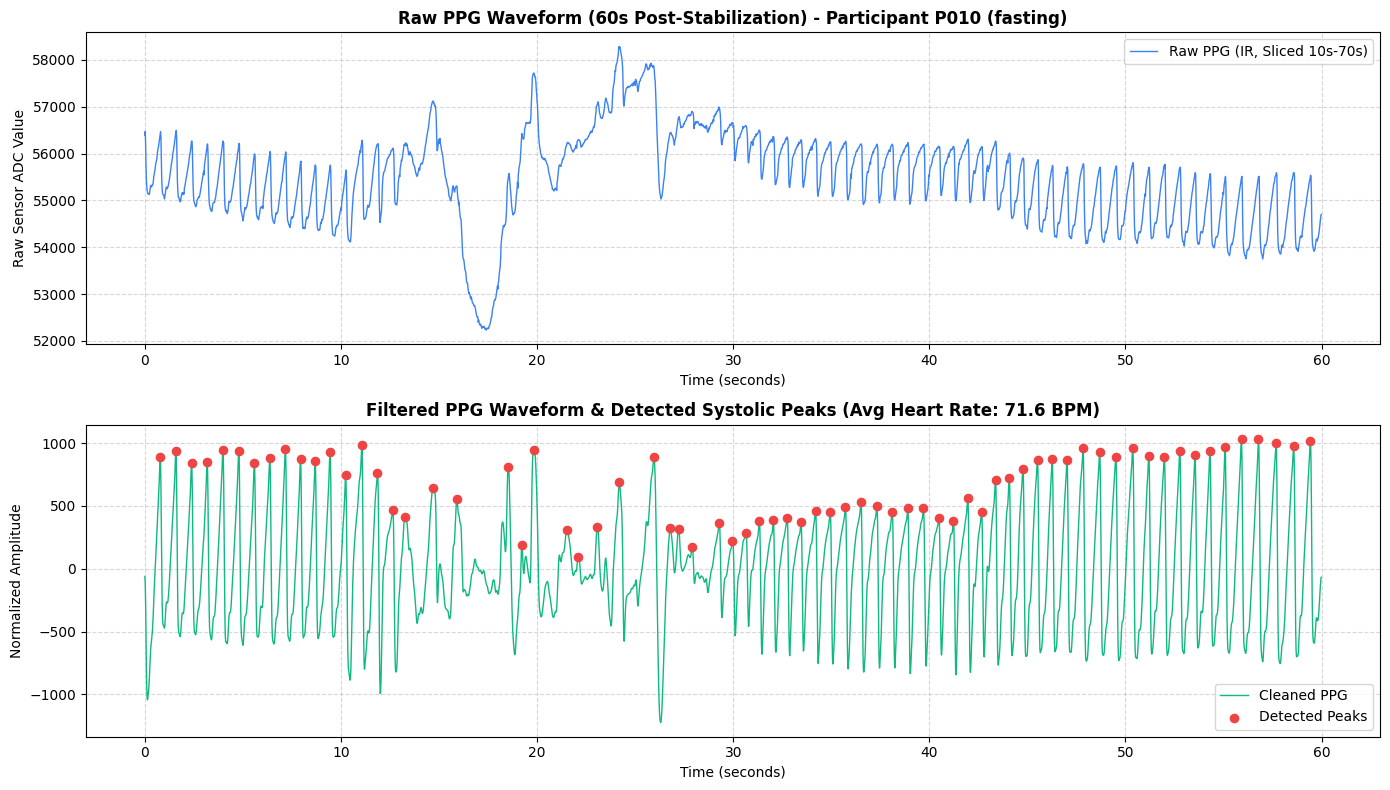


--- NeuroKit2 Built-in PPG Plotting ---


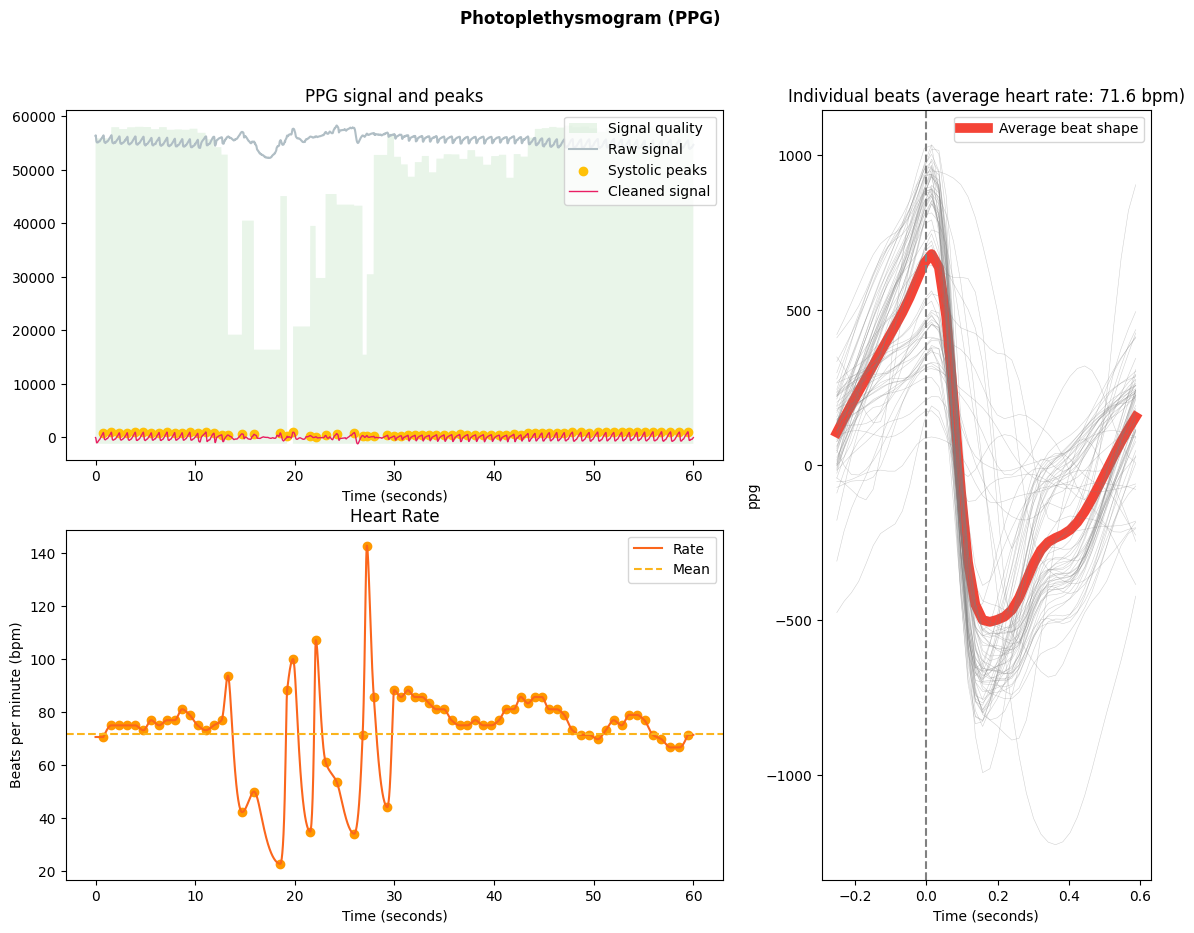

In [9]:
# Select a processed session from list (e.g. index 0 = Participant P001)
visual_session_idx = 30
session = processed_data[visual_session_idx]

ppg_signal = session['ppg_signal']
cleaned = session['cleaned']
peaks = session['peaks']
avg_hr = session['avg_hr']
row = session['row']

seconds_to_plot = 60
vis_samples = seconds_to_plot * sampling_rate
time = np.arange(vis_samples) / sampling_rate

# 1. Custom Matplotlib Visualization
plt.figure(figsize=(14, 8))

# Subplot 1: Raw PPG (Infrared Channel)
plt.subplot(2, 1, 1)
plt.plot(time, ppg_signal[:vis_samples], color='#3b82f6', linewidth=1.0, label='Raw PPG (IR, Sliced 10s-70s)')
plt.title(f"Raw PPG Waveform (60s Post-Stabilization) - Participant {row['participant_id']} ({row['session_kind']})", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Raw Sensor ADC Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: Filtered PPG & Peak Detection
plt.subplot(2, 1, 2)
plt.plot(time, cleaned[:vis_samples], color='#10b981', linewidth=1.0, label='Cleaned PPG')
plt.scatter(np.array(peaks) / sampling_rate, cleaned[peaks], color='#ef4444', marker='o', s=35, zorder=3, label='Detected Peaks')

plt.title(f"Filtered PPG Waveform & Detected Systolic Peaks (Avg Heart Rate: {avg_hr:.1f} BPM)", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 2. NeuroKit2 Built-in PPG Visualization
if 'signals' in session and 'info' in session:
    print("\n--- NeuroKit2 Built-in PPG Plotting ---")
    nk.ppg_plot(session['signals'], session['info'])
    fig = plt.gcf()
    fig.set_size_inches(14, 10)
    plt.show()